# Machine Learning #05 — Autoencoders & Variational Autoencoders 🖼️🔀

In the previous lessons our networks learned to **classify** — they needed labels.
Today the network learns **without any labels**: it learns to **compress data and
reconstruct it back**. This is our first *unsupervised* deep-learning model.

Everything runs in **PyTorch**, and we build it up in three steps:

> **image → encoder → latent vector → decoder → reconstructed image**

**Roadmap** 🗺️
- 🧠 **Autoencoder (AE)** — compress & reconstruct MNIST digits.
- 🚨 **Outlier detection** — reuse the trained AE: *what it cannot reconstruct is suspicious*.
- 🔀 **Variational Autoencoder (VAE)** — a **probabilistic** latent space we can
  **sample from to generate brand-new digits**.

At the end there are **5 hands-on activities** ✏️.

## What is an autoencoder? 🔎

An **autoencoder** is a neural network trained to **copy its input to its output** —
but through a narrow **bottleneck** that forces it to keep only the essentials.

It has **two parts**:

- **Encoder** 🗜️ — compresses the input image into a small **latent vector**
  (the *bottleneck* / *code*). The network decides on its own what to store —
  ideally the important features (stroke thickness, slant, shape).
- **Decoder** 🔁 — reconstructs the original image back from that latent vector.

The trick is in the training data: **the target is the input itself.** We minimise
the difference between the input image and its reconstruction. No class labels needed.

### Why binary cross-entropy (BCE)?

MNIST pixels are normalised to $[0, 1]$, so we can treat each pixel as a probability
and compare it with **BCE**:

$$\text{BCE} = -\frac{1}{N}\sum_{i=1}^{N}\big[\,y_i \log(p_i) + (1-y_i)\log(1-p_i)\,\big]$$

where $y_i$ is the true pixel and $p_i$ the reconstructed pixel.

> 💡 **BCE is asymmetric.** During backprop it cares more about pushing pixels to
> very dark (0) or very bright (1) than about the mid-tones (~0.5). That is usually
> fine for MNIST, where most pixels are near black or white.

### Autoencoder vs. classifier — different goals 🎯

Both a classifier and an autoencoder produce a latent vector, but they optimise for
**different things**:

| | Autoencoder | Classifier |
|---|---|---|
| Latent goal | keep enough info to **reconstruct** the image | make classes **easy to separate** |
| Loss | reconstruction (BCE) | cross-entropy over classes |
| Labels | **none** (unsupervised) | required (supervised) |
| Latent shape | preserves visual detail | pushes classes apart |

**TL;DR:** use classifiers for classification and autoencoders for autoencoder tasks —
the loss function is what shapes the latent space.

## Imports and setup ⚙️

Remember to set a **GPU** runtime in Colab! (*Runtime → Change runtime type → GPU*)

In [ ]:
!pip install torchinfo

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms

import torchinfo
from tqdm.auto import tqdm

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Use the GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch version:", torch.__version__)
print("device:", device)

torch version: 2.6.0+cu124
device: cuda


c:\Users\recka\Desktop\alex\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## The data — MNIST 🔢

MNIST is the classic dataset of handwritten digits (0–9), 28×28 grayscale.

⚠️ **One design choice up front:** we **resize the images to 32×32**.

Our encoder halves the width/height with every pooling step. Starting from 28 we get
`28 → 14 → 7 → ...` and **7 is odd** — integer division breaks the perfect
reconstruction (`7 // 2 = 3`, but `3 × 2 = 6 ≠ 7`). Starting from 32 (a power of two)
everything divides cleanly:

$$32 \rightarrow 16 \rightarrow 8 \rightarrow 4 \rightarrow 2 \rightarrow 1 \quad ✅$$

We use **one** torchvision pipeline for the *whole* notebook (both the AE and the VAE).

### Train / validation / test 🔀

We keep the honest three-way split used across this course:

1. **Train** (50 000) — the model learns from these.
2. **Validation** (10 000) — split off the training set; we watch the loss here **during**
   training to spot overfitting. The model never learns from it directly.
3. **Test** (10 000) — the untouched MNIST test set, used only at the end for
   reconstructions, outlier detection and generation.

In [2]:
transform = transforms.Compose([
    transforms.Resize(32),   # 28x28 -> 32x32  
    transforms.ToTensor(),   # PIL image -> tensor of shape (1, 32, 32), values in [0, 1]
])

from torch.utils.data import random_split

full_train = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)


val_size   = 10_000
train_size = len(full_train) - val_size
train_subset, val_subset = random_split(
    full_train, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),
)

train_loader = DataLoader(train_subset, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_subset,   batch_size=128, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=128, shuffle=False)

print("Train images:     ", len(train_subset))
print("Validation images:", len(val_subset))
print("Test images:      ", len(test_dataset))

Train images:      50000
Validation images: 10000
Test images:       10000


In [3]:
images, labels = next(iter(train_loader))
print("Batch shape:", images.shape)
print("Pixel range:", images.min().item(), "->", images.max().item())

Batch shape: torch.Size([128, 1, 32, 32])
Pixel range: 0.0 -> 1.0


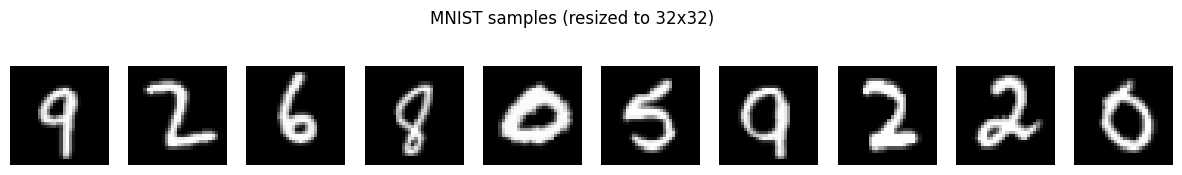

In [4]:
def show_images(images, n=10, title=None):
    images = images.detach().cpu().numpy()
    plt.figure(figsize=(15, 2.2))
    for i in range(n):
        ax = plt.subplot(1, n, i + 1)
        plt.imshow(images[i].squeeze(), cmap="gray")
        ax.axis("off")
    if title:
        plt.suptitle(title)
    plt.show()

show_images(images, title="MNIST samples (resized to 32x32)")

## Build the autoencoder 🧠

We build the AE as an **`nn.Module`** class. It has an `encoder`, a `decoder`, and a **latent vector** in between.

**Encoder** — two `Conv2d` + `MaxPool2d` blocks shrink the image `32 → 16 → 8`,
then a `Linear` layer squeezes everything into a `latent_dim`-sized vector.

**Decoder** — the mirror image: a `Linear` layer expands the vector back, then
**`ConvTranspose2d`** layers (a *learnable* upsampling) grow it `8 → 16 → 32`.

- The final activation is **`Sigmoid`**, squeezing outputs into $(0, 1)$ to match the
  normalised pixels.
- `padding=1` keeps the spatial size after each conv; `output_padding=1` makes the
  transposed conv land exactly on the doubled size.

In [5]:
class ConvAutoencoder(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder: 32x32 -> 16x16 -> 8x8 -> flatten -> latent vector
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                              # 32 -> 16
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                              # 16 -> 8
            nn.Flatten(),                                 # 32 * 8 * 8 = 2048
            nn.Linear(32 * 8 * 8, latent_dim),            # the bottleneck!
        )

        # Decoder: latent vector -> 8x8 -> 16x16 -> 32x32
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32 * 8 * 8), nn.ReLU(),
            nn.Unflatten(1, (32, 8, 8)),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),  # 8 -> 16
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1), nn.Sigmoid(), # 16 -> 32
        )

    def forward(self, x):
        z = self.encoder(x)      # compress
        out = self.decoder(z)    # reconstruct
        return out


model = ConvAutoencoder(latent_dim=32).to(device)
print(model)

ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=2048, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=2048, bias=True)
    (1): ReLU()
    (2): Unflatten(dim=1, unflattened_size=(32, 8, 8))
    (3): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (4): ReLU()
    (5): ConvTranspose2d(16, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (6): Sigmoid()
  )
)


In [6]:
torchinfo.summary(model, input_size=(1, 1, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
ConvAutoencoder                          [1, 1, 32, 32]            --
├─Sequential: 1-1                        [1, 32]                   --
│    └─Conv2d: 2-1                       [1, 16, 32, 32]           160
│    └─ReLU: 2-2                         [1, 16, 32, 32]           --
│    └─MaxPool2d: 2-3                    [1, 16, 16, 16]           --
│    └─Conv2d: 2-4                       [1, 32, 16, 16]           4,640
│    └─ReLU: 2-5                         [1, 32, 16, 16]           --
│    └─MaxPool2d: 2-6                    [1, 32, 8, 8]             --
│    └─Flatten: 2-7                      [1, 2048]                 --
│    └─Linear: 2-8                       [1, 32]                   65,568
├─Sequential: 1-2                        [1, 1, 32, 32]            --
│    └─Linear: 2-9                       [1, 2048]                 67,584
│    └─ReLU: 2-10                        [1, 2048]                 --
│  

## Train the autoencoder ⭐


> 🔑 **The target is the input.** We compute the loss between the reconstruction and the
> **original image** — `criterion(recon, images)` — not against any label.

For each batch we always do the same five steps:
`zero_grad → forward → loss → backward → step`.

In [7]:
criterion = nn.BCELoss()                                   # pixels in [0,1] -> BCE
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
n_epochs  = 5

train_losses, val_losses = [], []
for epoch in range(n_epochs):
    # ---- training ----
    model.train()
    running = 0.0
    for images, _ in train_loader:            # labels are ignored -> unsupervised
        images = images.to(device)

        optimizer.zero_grad()                 # 1) clear old gradients
        recon = model(images)                 # 2) forward pass
        loss  = criterion(recon, images)      # 3) loss vs the INPUT itself (key!)
        loss.backward()                       # 4) backprop
        optimizer.step()                      # 5) update the weights

        running += loss.item() * images.size(0)
    train_loss = running / len(train_subset)

    # ---- validation (no gradients, model in eval mode) ----
    model.eval()
    v_running = 0.0
    with torch.no_grad():
        for images, _ in val_loader:
            images = images.to(device)
            v_running += criterion(model(images), images).item() * images.size(0)
    val_loss = v_running / len(val_subset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"Epoch {epoch + 1}/{n_epochs}   train = {train_loss:.4f}   val = {val_loss:.4f}")

Epoch 1/5   train = 0.2164   val = 0.1279
Epoch 2/5   train = 0.1210   val = 0.1164
Epoch 3/5   train = 0.1144   val = 0.1127
Epoch 4/5   train = 0.1115   val = 0.1104
Epoch 5/5   train = 0.1098   val = 0.1091


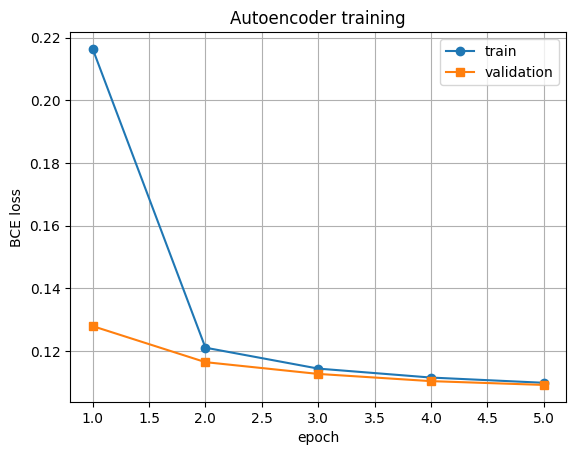

In [ ]:
plt.figure()
plt.plot(range(1, n_epochs + 1), train_losses, marker="o", label="train")
plt.plot(range(1, n_epochs + 1), val_losses,   marker="s", label="validation")
plt.xlabel("epoch")
plt.ylabel("BCE loss")
plt.title("Autoencoder training")
plt.legend()
plt.grid(True)
plt.show()

> 💡 Both curves should **go down** every epoch. Watch the **gap** between them: if the
> validation loss stops falling (or rises) while the training loss keeps dropping, the model
> is starting to **overfit**.

## How good are the reconstructions? 🖼️

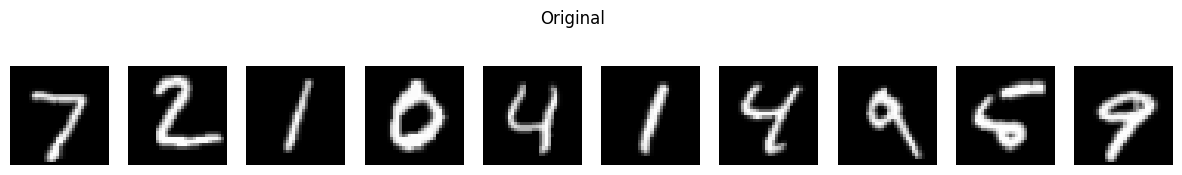

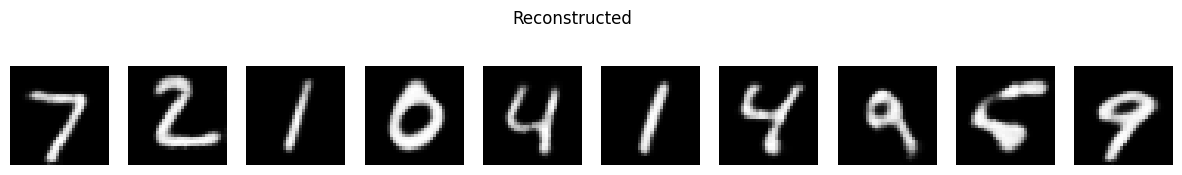

In [9]:
model.eval()
test_images, _ = next(iter(test_loader))
test_images = test_images.to(device)

with torch.no_grad():
    reconstructed = model(test_images)

show_images(test_images,   title="Original")
show_images(reconstructed, title="Reconstructed")

## Looking inside: the latent vectors ⚡

Let's make the bottleneck concrete. We take **one** digit and follow it through the
whole autoencoder:

- **Left** — the original image: **1024 pixels** (32×32).
- **Middle** — its **latent code**: the 32 numbers the encoder squeezed it into.
  Notice the values are **not** limited to [0, 1] — the bottleneck is a plain `Linear`
  layer, so they can be any real number (positive or negative).
- **Right** — the **reconstruction** the decoder rebuilds *from those 32 numbers alone*.

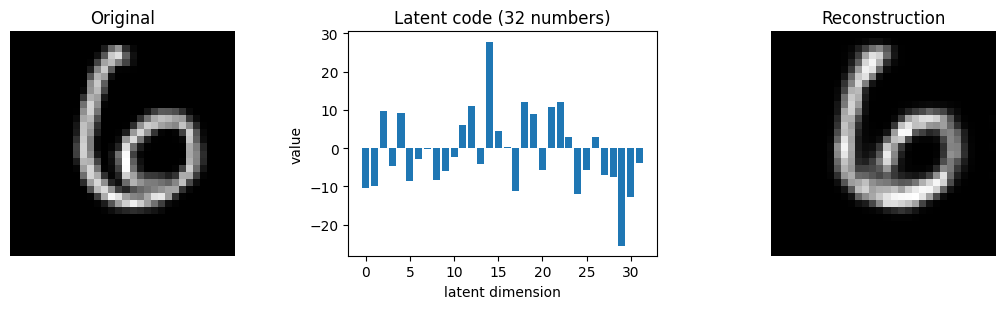

In [10]:
# Pick one test digit and show the compression end-to-end:
# original image  ->  its 32 latent numbers  ->  reconstruction
model.eval()
img, _ = test_dataset[100]                # one image, shape (1, 32, 32)
img = img.unsqueeze(0).to(device)        # add batch dim -> (1, 1, 32, 32)

with torch.no_grad():
    z = model.encoder(img)               # the 32 latent numbers
    recon = model.decoder(z)             # reconstruct from them

z = z.squeeze().cpu().numpy()            # (32,)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))

# 1) original
axes[0].imshow(img.squeeze().cpu().numpy(), cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

# 2) the latent vector as a bar chart
axes[1].bar(range(len(z)), z)
axes[1].set_title(f"Latent code ({len(z)} numbers)")
axes[1].set_xlabel("latent dimension")
axes[1].set_ylabel("value")

# 3) reconstruction
axes[2].imshow(recon.squeeze().cpu().numpy(), cmap="gray")
axes[2].set_title("Reconstruction")
axes[2].axis("off")

plt.tight_layout()
plt.show()

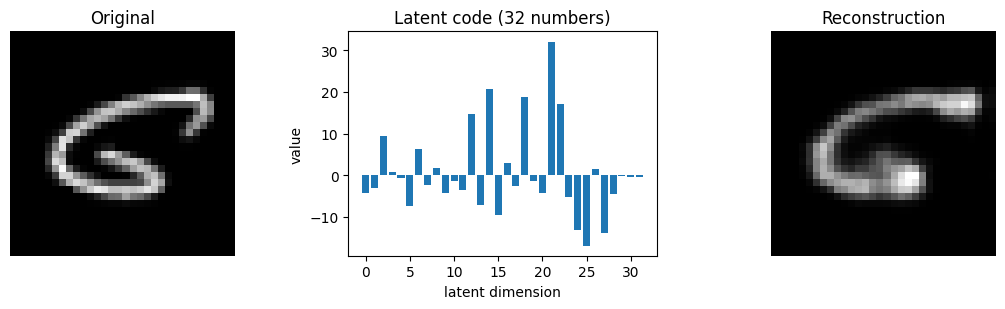

In [11]:

model.eval()
img, _ = test_dataset[1014]              
img = img.unsqueeze(0).to(device)

with torch.no_grad():
    z = model.encoder(img)
    recon = model.decoder(z)

z = z.squeeze().cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))

axes[0].imshow(img.squeeze().cpu().numpy(), cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].bar(range(len(z)), z)
axes[1].set_title(f"Latent code ({len(z)} numbers)")
axes[1].set_xlabel("latent dimension")
axes[1].set_ylabel("value")

axes[2].imshow(recon.squeeze().cpu().numpy(), cmap="gray")
axes[2].set_title("Reconstruction")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## Outlier detection with the autoencoder 🚨

> ### 📌 If you cannot compress it, something is probably wrong with it.

Our AE was trained almost entirely on **normal** digits, so it reconstructs them well
(**low** reconstruction error). Feed it something **weird** — a heavily corrupted image —
and it reconstructs it **badly** (**high** error). That error becomes an outlier score.

**Recipe:**
1. Take some clean test digits.
2. Make a corrupted ("outlier") copy by adding strong noise.
3. Measure the **reconstruction error** $\lVert x - \hat{x}\rVert^2$ for both.
4. Compare the two error distributions.

Real-world outliers this idea catches: fraudulent transactions, faulty sensor readings,
unusual medical measurements — anything that "doesn't compress like the rest".

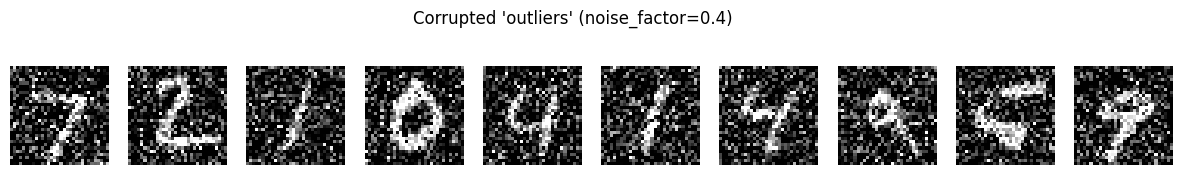

In [12]:
# 1) clean samples + 2) noisy ("outlier") copies
clean, _ = next(iter(DataLoader(test_dataset, batch_size=200, shuffle=False)))
clean = clean.to(device)

noise_factor = 0.4
noisy = torch.clamp(clean + noise_factor * torch.randn_like(clean), 0.0, 1.0)

# 3) reconstruction error per image: || x - reconstruction(x) ||^2
model.eval()
with torch.no_grad():
    recon_clean = model(clean)
    recon_noisy = model(noisy)

err_clean = ((clean - recon_clean) ** 2).flatten(1).sum(1).cpu().numpy()
err_noisy = ((noisy - recon_noisy) ** 2).flatten(1).sum(1).cpu().numpy()

# show a few noisy inputs
show_images(noisy, title=f"Corrupted 'outliers' (noise_factor={noise_factor})")

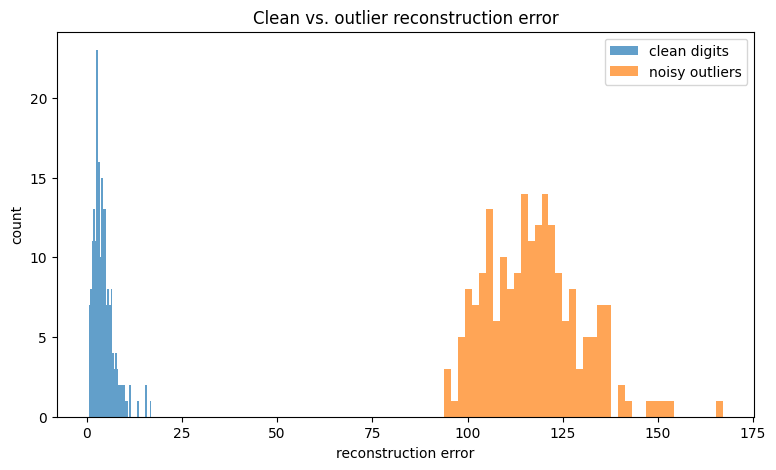

In [ ]:
# 4) the two error distributions should be clearly separated
plt.figure(figsize=(9, 5))
plt.hist(err_clean, bins=40, alpha=0.7, label="clean digits")
plt.hist(err_noisy, bins=40, alpha=0.7, label="noisy outliers")
plt.xlabel("reconstruction error")
plt.ylabel("count")
plt.title("Clean vs. outlier reconstruction error")
plt.legend()
plt.show()

# Variational Autoencoder (VAE) 📒

A plain autoencoder maps each image to **one point** in latent space. That is great for
reconstruction, but the latent space is full of **holes** — sample a random point and the
decoder often produces garbage. So a plain AE cannot reliably **generate** new images.

A **VAE** fixes this by encoding each image into a **probability distribution** instead of
a single point:

- the encoder outputs a **mean** `z_mean` ($\mu$) and a **log-variance** `z_log_var`
  ($\log \sigma^2$) for each latent dimension,
- we **sample** a latent vector from that distribution,
- the decoder reconstructs from the sample.

This forces the latent space to be **smooth and continuous**: nearby points decode to
similar images, so we can **sample from $\mathcal{N}(0, 1)$ and generate brand-new digits**. ✨

## The reparameterisation trick 🎲 — the heart of the VAE

There is a problem: sampling is **random**, and you cannot backpropagate through a random
node. The **reparameterisation trick** moves the randomness *outside* the network so
gradients can still flow:

$$z = \mu + \sigma \odot \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, 1)$$

- $\mu$ (`z_mean`) — where the encoder places the image,
- $\sigma$ (`= exp(0.5 · z_log_var)`) — how much it is allowed to wander,
- $\varepsilon$ — pure external noise, independent of the network.

| | latent sampling |
|---|---|
| **Without the trick** | $z \sim \mathcal{N}(\mu, \sigma^2)$ — randomness *inside* → ❌ no gradients |
| **With the trick** | $z = \mu + \sigma \cdot \varepsilon$ — randomness *outside* → ✅ gradients flow through $\mu, \sigma$ |

> 💡 We keep `z_log_var` (log-variance) instead of the variance directly. It can take
> any real value (negative or positive), which is numerically friendlier, and
> `exp(0.5 · z_log_var)` always gives a positive standard deviation.

## The VAE loss = reconstruction + KL 💡

We must write this loss ourselves. It has **two terms**:

$$\mathcal{L} = \underbrace{\text{BCE}(\hat{x}, x)}_{\text{reconstruct well}}
\;+\; \underbrace{\left(-\tfrac{1}{2}\sum_{j}\big(1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2\big)\right)}_{\text{KL divergence}}$$

- **Reconstruction (BCE)** — same as before: the output must look like the input.
- **KL divergence** — pulls every encoded distribution towards a standard normal
  $\mathcal{N}(0, 1)$. It is **0** when $\mu = 0$ and $\sigma = 1$, and grows as the
  encoder drifts away.

## Build the VAE 🔀

Three new ingredients compared to the plain AE:

1. **`Sampling`** — a tiny module implementing the reparameterisation trick.
2. **Two output heads** `z_mean` and `z_log_var` instead of one latent vector.
3. **`forward` returns three things** — `reconstruction, z_mean, z_log_var` — because the
   loss needs all of them.

In [14]:
class Sampling(nn.Module):
    # Reparameterisation trick:  z = mean + std * epsilon,  epsilon ~ N(0, 1)
    def forward(self, z_mean, z_log_var):
        epsilon = torch.randn_like(z_mean)               # external noise ~ N(0,1)
        return z_mean + torch.exp(0.5 * z_log_var) * epsilon

In [15]:
class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder: 32x32 -> 16x16 -> 8x8 -> flatten
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                       # 32 -> 16
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                       # 16 -> 8
            nn.Flatten(),                          # 64 * 8 * 8 = 4096
        )
        # Two heads describing the latent DISTRIBUTION (not a single point)
        self.z_mean    = nn.Linear(64 * 8 * 8, latent_dim)   # mean  (mu)
        self.z_log_var = nn.Linear(64 * 8 * 8, latent_dim)   # log-variance (log sigma^2)
        self.sampling  = Sampling()

        # Decoder: latent -> 8x8 -> 16x16 -> 32x32
        self.decoder_input = nn.Linear(latent_dim, 64 * 8 * 8)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (64, 8, 8)),
            nn.ConvTranspose2d(64, 64, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),  # 8 -> 16
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),  # 16 -> 32
            nn.Conv2d(32, 1, 3, padding=1), nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.z_mean(h), self.z_log_var(h)

    def decode(self, z):
        h = self.decoder_input(z)
        return self.decoder(h)

    def forward(self, x):
        z_mean, z_log_var = self.encode(x)
        z = self.sampling(z_mean, z_log_var)
        return self.decode(z), z_mean, z_log_var


# latent_dim = 2 so we can later plot the latent space in 2D
vae = VAE(latent_dim=2).to(device)
torchinfo.summary(vae, input_size=(1, 1, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
VAE                                      [1, 1, 32, 32]            --
├─Sequential: 1-1                        [1, 4096]                 --
│    └─Conv2d: 2-1                       [1, 32, 32, 32]           320
│    └─ReLU: 2-2                         [1, 32, 32, 32]           --
│    └─MaxPool2d: 2-3                    [1, 32, 16, 16]           --
│    └─Conv2d: 2-4                       [1, 64, 16, 16]           18,496
│    └─ReLU: 2-5                         [1, 64, 16, 16]           --
│    └─MaxPool2d: 2-6                    [1, 64, 8, 8]             --
│    └─Flatten: 2-7                      [1, 4096]                 --
├─Linear: 1-2                            [1, 2]                    8,194
├─Linear: 1-3                            [1, 2]                    8,194
├─Sampling: 1-4                          [1, 2]                    --
├─Linear: 1-5                            [1, 4096]                 12,288


In [16]:
def vae_loss(recon_x, x, z_mean, z_log_var):
    # Reconstruction term: summed BCE over all pixels
    recon = F.binary_cross_entropy(recon_x, x, reduction="sum")
    # KL divergence: pull the latent distribution towards N(0, 1)
    kl = -0.5 * torch.sum(1 + z_log_var - z_mean.pow(2) - z_log_var.exp())
    return recon + kl

## Train the VAE ⭐

Same five-step loop as before — only the forward pass now returns three values, and we
call our custom `vae_loss`. We wrap the loader in `tqdm` for a progress bar.

In [17]:
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)
n_epochs  = 10

vae_train_losses, vae_val_losses = [], []
for epoch in range(n_epochs):
    # ---- training ----
    vae.train()
    running = 0.0
    for images, _ in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{n_epochs}", leave=False):
        images = images.to(device)

        optimizer.zero_grad()
        recon, z_mean, z_log_var = vae(images)                 # forward: 3 outputs
        loss = vae_loss(recon, images, z_mean, z_log_var)      # BCE + KL
        loss.backward()
        optimizer.step()

        running += loss.item()
    train_loss = running / len(train_subset)

    # ---- validation ----
    vae.eval()
    v_running = 0.0
    with torch.no_grad():
        for images, _ in val_loader:
            images = images.to(device)
            recon, z_mean, z_log_var = vae(images)
            v_running += vae_loss(recon, images, z_mean, z_log_var).item()
    val_loss = v_running / len(val_subset)

    vae_train_losses.append(train_loss)
    vae_val_losses.append(val_loss)
    print(f"Epoch {epoch + 1}/{n_epochs}   train = {train_loss:.2f}   val = {val_loss:.2f}")

Epoch 1/10   train = 262.42   val = 231.78


Epoch 2/10   train = 228.51   val = 223.61


Epoch 3/10   train = 219.91   val = 217.42


Epoch 4/10   train = 215.93   val = 214.75


Epoch 5/10   train = 214.14   val = 213.48


Epoch 6/10   train = 212.74   val = 212.06


Epoch 7/10   train = 211.64   val = 211.07


Epoch 8/10   train = 210.77   val = 210.81


Epoch 9/10   train = 210.02   val = 210.19


Epoch 10/10   train = 209.50   val = 210.50


The VAE loss combines two terms, so its absolute value is large (summed over all
pixels) — only the **trend** matters. Train and validation should fall together.

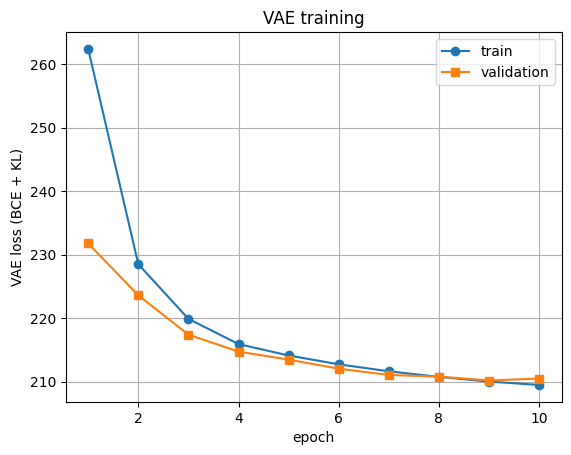

In [23]:
plt.figure()
plt.plot(range(1, n_epochs + 1), vae_train_losses, marker="o", label="train")
plt.plot(range(1, n_epochs + 1), vae_val_losses,   marker="s", label="validation")
plt.xlabel("epoch")
plt.ylabel("VAE loss (BCE + KL)")
plt.title("VAE training")
plt.legend()
plt.grid(True)
plt.show()

## Reconstructions from the VAE 🖼️

First a sanity check — the VAE should still reconstruct real inputs.

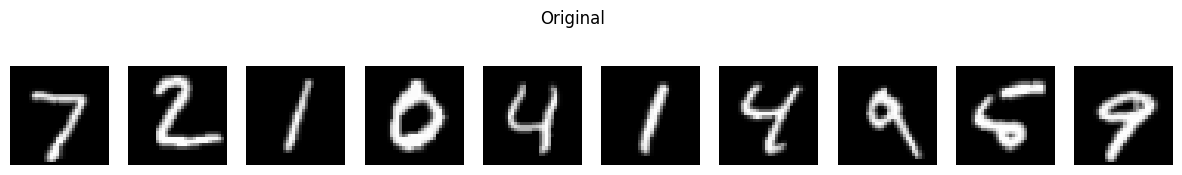

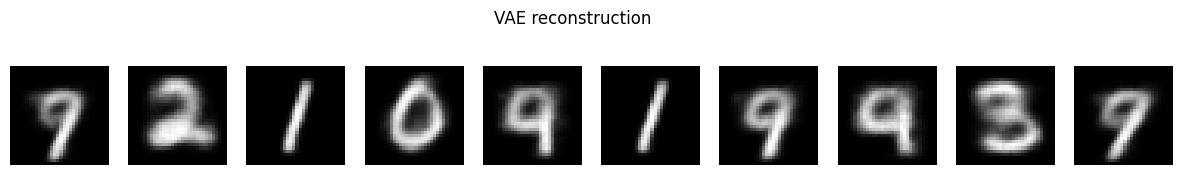

In [24]:
vae.eval()
test_images, test_labels = next(iter(test_loader))
test_images = test_images.to(device)

with torch.no_grad():
    recon, _, _ = vae(test_images)

show_images(test_images, title="Original")
show_images(recon,       title="VAE reconstruction")

> 🔎 The reconstructions look a bit **blurry**. That is expected: with only **2** latent
> dimensions we are compressing each digit into just two numbers. The blur is the price of
> a tiny latent space — and exactly what lets us visualise it below.

## Generating NEW digits 🤔✨

Here is the payoff. Because the KL term forced the latent space towards $\mathcal{N}(0,1)$,
we can **throw away the encoder**, sample random vectors from $\mathcal{N}(0,1)$, and let the
**decoder** turn them into digits that were never in the dataset.

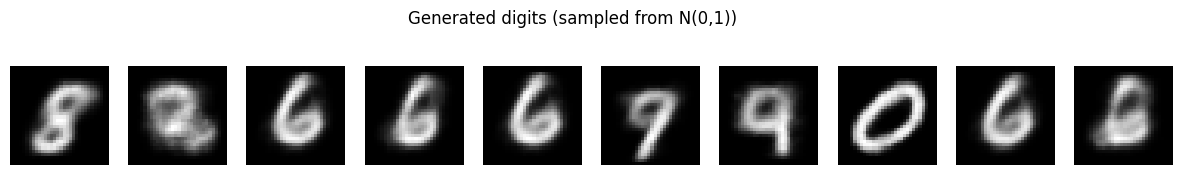

In [25]:
with torch.no_grad():
    z = torch.randn(10, vae.latent_dim).to(device)   # random points from N(0, 1)
    generated = vae.decode(z)

show_images(generated, title="Generated digits (sampled from N(0,1))")

## The latent manifold 📈

With a 2D latent we can sweep a grid of $(z_1, z_2)$ values and decode each one. This
paints the **whole space of digits** the VAE has learned — and you can watch one digit
morph smoothly into another.

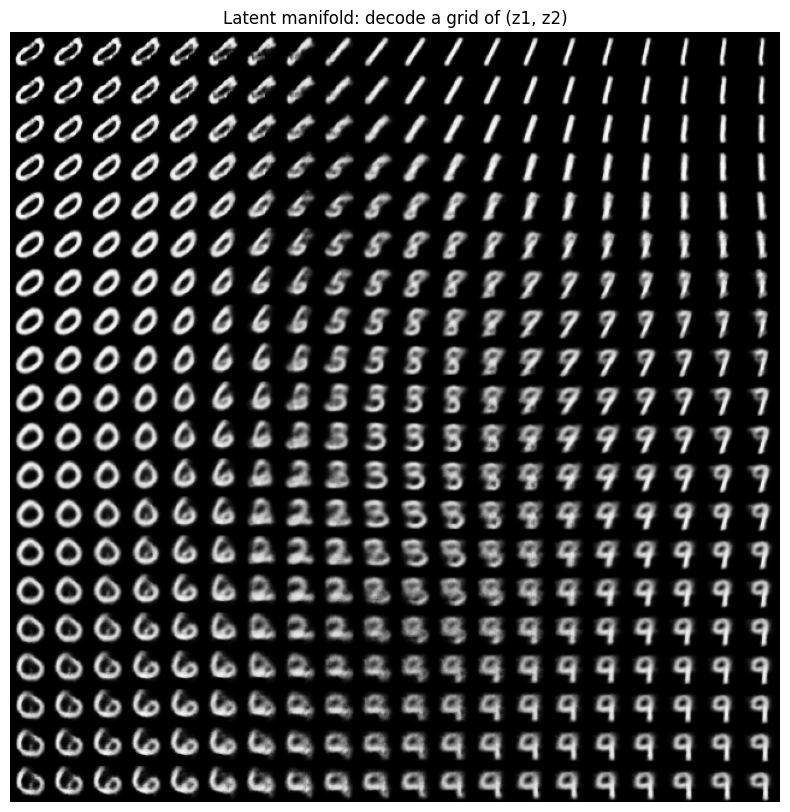

In [26]:
def plot_latent(model, n=20, scale=2.0, device=device):
    digit = 32
    grid_x = torch.linspace(-scale, scale, n)
    grid_y = torch.linspace(-scale, scale, n).flip(0)   # flip so +y points up

    canvas = np.zeros((digit * n, digit * n))
    model.eval()
    with torch.no_grad():
        for i, yi in enumerate(grid_y):
            for j, xi in enumerate(grid_x):
                z = torch.tensor([[xi.item(), yi.item()]], device=device)
                img = model.decode(z)[0, 0].cpu().numpy()
                canvas[i * digit:(i + 1) * digit, j * digit:(j + 1) * digit] = img

    plt.figure(figsize=(10, 10))
    plt.imshow(canvas, cmap="Greys_r")
    plt.title("Latent manifold: decode a grid of (z1, z2)")
    plt.axis("off")
    plt.show()

plot_latent(vae)

## Where does each digit live? 🗺️

Finally, encode many test digits and scatter their `z_mean` in 2D, coloured by their true
label. Digits that look alike end up **near each other** — a nicely organised latent space.

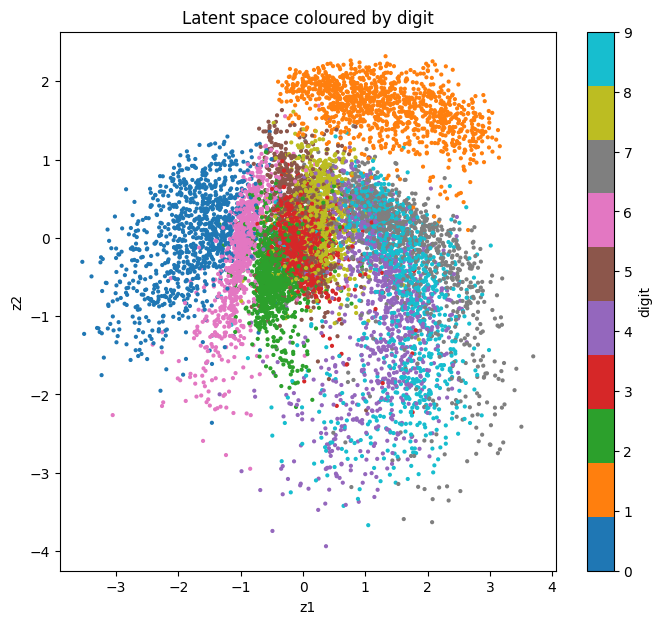

In [ ]:
zs, ys = [], []
vae.eval()
with torch.no_grad():
    for images, lbls in test_loader:
        m, _ = vae.encode(images.to(device))
        zs.append(m.cpu())
        ys.append(lbls)

zs = torch.cat(zs).numpy()
ys = torch.cat(ys).numpy()

plt.figure(figsize=(8, 7))
sc = plt.scatter(zs[:, 0], zs[:, 1], c=ys, cmap="tab10", s=4)
plt.colorbar(sc, ticks=range(10), label="digit")
plt.xlabel("z1")
plt.ylabel("z2")
plt.title("Latent space coloured by digit")
plt.show()

# Activities ✏️

## Activity 1 — Squeeze the bottleneck 🗜️

The `latent_dim` of the autoencoder controls how much information survives the bottleneck.

- Rebuild and retrain `ConvAutoencoder` with **three** different latent sizes,
  e.g. `8`, `32`, `128`.
- Show the reconstructions for each and compare.

## Activity 2 — Denoising autoencoder 🧽

A **denoising** autoencoder learns to *remove* noise: it receives a **noisy** image as
input but is trained to output the **clean** one.

- The cell below is **pre-filled** to build noisy/clean tensors — just run it.
- Then train an autoencoder where the **input is `noisy`** and the **target is `clean`**
  (i.e. `criterion(model(noisy_batch), clean_batch)`).
- Experiment with **`noise_factor` = 0.1, 0.5, 0.9** and write a short note on how well the
  model can recover the digits. 📒

In [ ]:
# --- pre-filled helper: build clean + noisy tensors you can train on ---
def make_noisy(dataset, noise_factor=0.5, n=10000):
    loader = DataLoader(dataset, batch_size=n, shuffle=True)
    clean, _ = next(iter(loader))
    noisy = torch.clamp(clean + noise_factor * torch.randn_like(clean), 0.0, 1.0)
    return clean, noisy

noise_factor = 0.5
clean_x, noisy_x = make_noisy(train_subset, noise_factor=noise_factor)

# quick look: top row = clean target, bottom row = noisy input
show_images(clean_x, title="Clean (target)")
show_images(noisy_x, title=f"Noisy input (noise_factor={noise_factor})")

# Tip: wrap them in a DataLoader for training
noisy_loader = DataLoader(TensorDataset(noisy_x, clean_x), batch_size=128, shuffle=True)

## Activity 3 — β-VAE: tune the KL weight ⚖️

The VAE loss balances reconstruction against the KL term. A **β-VAE** simply weights the
KL term by a factor **β**:

$$\mathcal{L} = \text{BCE} + \beta \cdot \mathcal{L}_{KL}$$

- Write a `vae_loss_beta(..., beta)` and retrain with e.g. `beta = 0.5`, `1.0`, `4.0`.
- Compare **reconstruction sharpness** vs. how **organised** the latent scatter looks.

## Activity 4 — Outlier threshold 🚨

Back to outlier detection. Using the reconstruction errors from the AE section:

- Pick a **threshold** on the reconstruction error (e.g. a high percentile of the clean
  errors) and flag everything above it as an outlier.
- Report how many clean vs. noisy images get flagged (a mini confusion matrix).